<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°8

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

In [1]:
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/anime.csv

--2025-11-05 11:26:38--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/anime.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14194341 (14M) [text/plain]
Saving to: ‘anime.csv’

anime.csv           100%[===================>]  13.54M  --.-KB/s    in 0.1s    

2025-11-05 11:26:39 (121 MB/s) - ‘anime.csv’ saved [14194341/14194341]



In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# a) Modelo de lenguaje

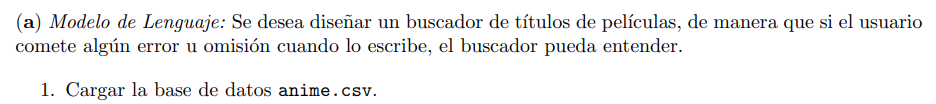

In [3]:
df = pd.read_csv('anime.csv')
display(df.head())
print(df.info())

,title,680973,682775,682809,684730,684840,684862,685362,686426,686489,...,1388155,1389510,1389679,1390094,1391050,1392101,1392278,1392522,1393478,1393558
0,"""Deji"" Meets Girl",-1.0,8.0,7.0,-1.0,5.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,"""Ippon"" again!",-1.0,-1.0,-1.0,-1.0,7.0,-1.0,-1.0,-1.0,2.0,...,-1.0,-1.0,-1.0,7.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0
2,"'Tis Time for ""Torture,"" Princess",-1.0,8.0,7.0,-1.0,8.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,8.0,-1.0,6.0,-1.0,-1.0,6.0,-1.0
3,"'Tis Time for ""Torture,"" Princess Season 2",-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,0 Years Old Child Starting Dash Story,-1.0,8.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Columns: 1001 entries, title to 1393558
dtypes: float64(1000), object(1)
memory usage: 22.7+ MB
None


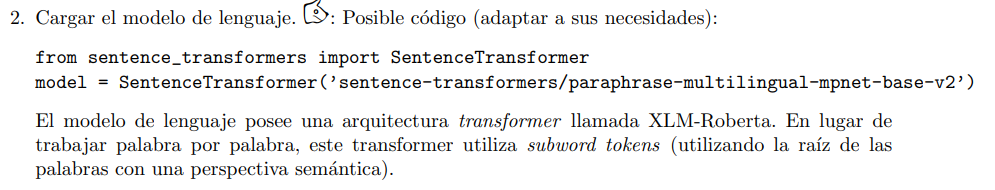

In [4]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

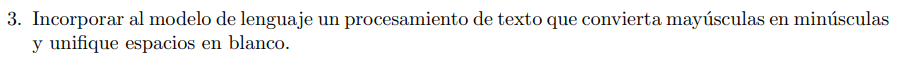

In [5]:
def pre_procesamiento(data): # quita mayúsculas y espacios en blanco. Sirve para strings individuales o listas de strings
    if isinstance(data, list):
        return [string.lower().replace(" ", "") for string in data]
    elif isinstance(data, str):
        return data.lower().replace(" ", "")
    else:
        return data
    #nota: instance es una realización de una clase (o tipo).


def pre_encode(data): #esta función engloba el preprocesamiento y el encoding
  if isinstance(data, pd.Series):
    data = data.astype(str).tolist()

  if isinstance(data, list):
    strings_pre = [pre_procesamiento(string) for string in data]
    return model.encode(strings_pre)

  elif isinstance(data, str):
    string_pre = pre_procesamiento(data)
    return model.encode(string_pre)

  else:
    return None

In [6]:
strings = ['texto en minúsculas', ' TEXTO EN MAYÚSCULAS']

print(pre_procesamiento(strings))

embs = pre_encode(strings)
print(embs)

['textoenminúsculas', 'textoenmayúsculas']
[[-0.00455669 -0.2265566  -0.01844961 ...  0.10765694 -0.01774577
  -0.04189491]
 [-0.00173382 -0.1512447  -0.0201553  ...  0.08945731 -0.0096501
  -0.04418185]]


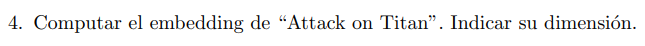

In [7]:
emb = pre_encode('Attack on Titan')
print(type(emb))
print(emb.shape)

<class 'numpy.ndarray'>
(768,)


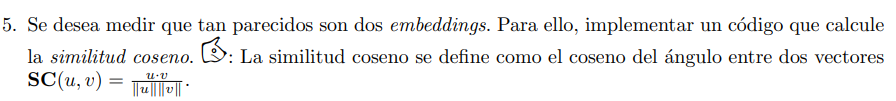

In [8]:
def SC (u, v):
  if not isinstance(u, np.ndarray):
    u = pre_encode(u)

  if not isinstance(v, np.ndarray):
    v = pre_encode(v)

  return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

In [27]:
string1 = 'Attack on Titan'
string2 = 'Atack on '
string3 = 'asdf'

print(SC(string1, string1))
print(SC(string1, string2))
print(SC(string1, string3))

0.99999994
0.6761673
0.31448385


La similitud coseno efectivamente mide la similitud entre las cadenas de caracteres

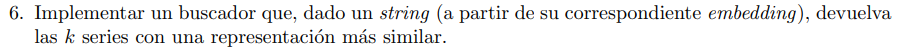

In [10]:
titulos = df['title']
embeddings_titulos = pre_encode(titulos) #esto lo hago a parte porque tarda mucho

In [11]:
print(type(embeddings_titulos))
print(embeddings_titulos.shape)

<class 'numpy.ndarray'>
(2966, 768)


In [12]:
def buscador(k, string):
  emb = pre_encode(string)
  #para cada título, calculo la SC entre el embedding del titulo y el del string que me pasaron
  #agarro los k títulos más parecidos
  SC_arr = np.zeros(len(embeddings_titulos))
  for i in range(len(embeddings_titulos)):
    SC_arr[i] = SC(emb, embeddings_titulos[i])


  indices = np.flip(np.argsort(SC_arr))[0:k] #argsort odena de menor a mayor. Lo tengo que dar vuelta
  return df['title'][indices]

In [13]:
print(buscador(5, 'Attack'))

201                         Attack on Titan
203                Attack on Titan Season 3
202                Attack on Titan Season 2
204         Attack on Titan Season 3 Part 2
206    Attack on Titan: Final Season Part 2
Name: title, dtype: object


El algorimto encuentra los 5 títulos más parecidos

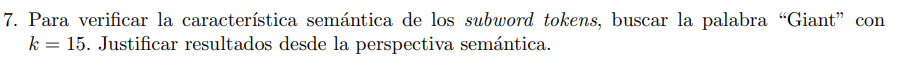

In [14]:
print(buscador(15, 'Giant'))

842                          Giant Killing
841                    Giant Beasts of Ars
2084                          SUPER HXEROS
2314                             Super Cub
1849                          Overlord III
1541                            Megane-bu!
2005                            Re:Monster
1539                             Megalobox
1847                              Overlord
1848                           Overlord II
384                             Bullbuster
1850                           Overlord IV
1542                       Megaton Musashi
2317    Super Robot Wars OG: The Inspector
2691                          Tower of God
Name: title, dtype: object


Observaciones: Los 2 primeros títulos más similares contienen la palabra 'Giant' al principio. Las siguientes palabras, si bien no tienen el término 'Giant' contienen términos con significados similares, como 'Overlord', 'Mega-' o 'Super'.

image.png

In [15]:
class Buscador:
  def __init__ (self, k, titulos, model):
    self.k = k
    self.titulos = titulos
    self.model = model
    self.titulos_emb = self.pre_encode(titulos)

  def pre_procesamiento(self, data):
    if isinstance(data, list):
        return [string.lower().replace(" ", "") for string in data]
    elif isinstance(data, str):
        return data.lower().replace(" ", "")
    else:
        return data

  def pre_encode(self, data):
    if isinstance(data, pd.Series):
      data = data.astype(str).tolist()

    if isinstance(data, list):
      strings_pre = [self.pre_procesamiento(string) for string in data]
      return self.model.encode(strings_pre)

    elif isinstance(data, str):
      string_pre = self.pre_procesamiento(data)
      return self.model.encode(string_pre)

    else:
      return None

  def SC(self, u, v):
    if not isinstance(u, np.ndarray):
      u = self.pre_encode(u)

    if not isinstance(v, np.ndarray):
      v = self.pre_encode(v)

    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

  def buscar(self, titulo):
    titulo_emb = self.pre_encode(titulo)

    SC_arr = np.zeros(len(self.titulos_emb))

    for i in range(len(self.titulos_emb)):
      SC_arr[i] = SC(titulo_emb, self.titulos_emb[i])

    indices = np.flip(np.argsort(SC_arr))[0:self.k] #argsort odena de menor a mayor. Lo tengo que dar vuelta
    return self.titulos[indices]

In [16]:
buscador = Buscador(k = 15, titulos = df['title'], model = model)

In [17]:
print(buscador.buscar('Giant'))

842                          Giant Killing
841                    Giant Beasts of Ars
2084                          SUPER HXEROS
2314                             Super Cub
1849                          Overlord III
1541                            Megane-bu!
2005                            Re:Monster
1539                             Megalobox
1847                              Overlord
1848                           Overlord II
384                             Bullbuster
1850                           Overlord IV
1542                       Megaton Musashi
2317    Super Robot Wars OG: The Inspector
2691                          Tower of God
Name: title, dtype: object


# b) Sistema de recomendación

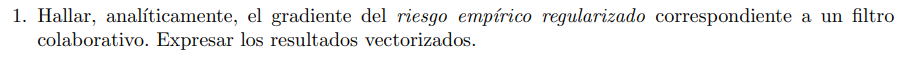

La función costo a minimizar es:

$$
J(X, \Theta)=\frac{1}{2}\sum_i\sum_j (\theta_j^T\cdot x_i-y_{i, j})^2 + \frac{\lambda}{2} \cdot ( \sum_i ||x_i||^2 + \sum_j ||\theta_j||^2 )
$$

donde la doble sumatoria se hace para los $(i, j)$ en los que se tiene un $y_{i, j}$ distinto de $-1$. Además, las matrices $X$ y $\Theta$ son:

$$
X =
\begin{bmatrix}
x_1^T \\
x_2^T \\
\vdots \\
x_{n_{items}}^T
\end{bmatrix}
$$

y

$$
\Theta =
\begin{bmatrix}
\theta_1^T \\
\theta_2^T \\
\vdots \\
\theta_{n_{users}}^T
\end{bmatrix}
$$

Las dimensiones son: $X ∈ (n_{items}, \nu)$ y $\Theta \in (n_{users}, \nu)$, es decir, cada vector $x_i$ o $\theta_j$ está en el espacio $ℝ^{\nu}$

Derivo $J$ para algún $x_i$:

$$
\frac{dJ}{dx_i} = \sum_j (\theta_j^T \cdot x_i -_{} y_{i, j}) \cdot \theta_j + \lambda x_i
$$

Derivo $J$ para algún $\theta_j$:

$$
\frac{dJ}{d\theta_j} = \sum_i (\theta_j^T \cdot x_i -_{} y_{i, j}) \cdot x_i + \lambda \theta_j
$$

Para no tener que actualizar cada $x_i$ y cada $\theta_j$ individualmente, sería conveniente expresar el algoritmo de la siguiente manera:

$$
X → X - \alpha \cdot ∇_X J
$$

donde

$$
∇_X J = \begin{bmatrix}
\frac{dJ}{dx_1} \\
\frac{dJ}{dx_2}\\
\vdots \\
\frac{dJ}{dx_{n_{items}}}
\end{bmatrix}
$$

A partir de las derivadas respecto de cada $x_i$, se puede comprobar que:

$$
∇_X J = (X \Theta^T - Y) \cdot \Theta + \lambda X
$$

Además, para no incluir los términos que no tienen valoración, hay que multiplicar elemento a elemento por una matriz máscara, que denomino $R$

$$
R_{i, j} = 𝟙 \{ {y_{i, j}} \text{ tiene valoración} \}
$$

Entonces:

$$
\nabla_X J = ∇_X J = (X \Theta^T - Y) ⊙ R \cdot \Theta + \lambda X = E \cdot \Theta + \lambda X
$$

Donde el símbolo $\odot$ representa el producto elemento a elemento y, por simplicidad, se define $E =  (X \Theta^T - Y) ⊙ R$, $E \in ℝ^{n_i, n_u}$

Procediendo de manera análoga, se llega a que

$$
\Theta → \Theta - α ∇_{\Theta} J
$$

donde

$$
∇_{Θ} J = E^T \cdot X + \lambda Θ
$$

En resumen:

$$
∇_X J = E\cdot \Theta + λ X
$$

y

$$
\nabla _ {Θ} J = E^T \cdot X + λ\Theta
$$

donde $E = (X \cdot \Theta^T - Y) \odot R$

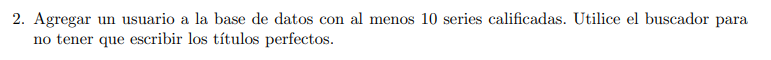

In [18]:
buscador.k = 5
buscador.buscar('pokemon')

,title
1910,Pokémon the Series: XYZ
1906,Pokémon Horizons: The Series
1915,Pokémon: To Be a Pokémon Master
1911,Pokémon: Black & White
1909,Pokémon the Series: XY


In [19]:
buscador.k = 3
dragon_ball = buscador.buscar('Dragon ball')
pokemon = buscador.buscar('pokemon')
buscador.k = 4
naruto = buscador.buscar('naruto')

series_nuevo_usuario = pd.concat([dragon_ball, pokemon, naruto])
display(series_nuevo_usuario)


,title
646,Dragon Ball Super
648,Dragon Collection
653,Dragonar Academy
1910,Pokémon the Series: XYZ
1906,Pokémon Horizons: The Series
1915,Pokémon: To Be a Pokémon Master
1704,Naruto (Shinsaku Anime)
1747,Ninja Kamui
1330,Konohana Kitan
1768,Noragami


In [20]:
df = pd.read_csv('anime.csv')
df.shape

(2966, 1001)

In [41]:
nuevo_usuario = 'nuevo_usuario_1'
df[nuevo_usuario] = -1.0

puntuaciones = [1, 2, 3, 8, 7, 8, 0, 4, 2, 1] #le gusta mucho pokemon. No le gusta nada dragon ball ni naruto

df.loc[df['title'].isin(series_nuevo_usuario), nuevo_usuario] = puntuaciones


display(df.loc[df['title'].isin(series_nuevo_usuario), nuevo_usuario])

,nuevo_usuario_1
646,1.0
648,2.0
653,3.0
1330,8.0
1704,7.0
1747,8.0
1768,0.0
1906,4.0
1910,2.0
1915,1.0


In [42]:
df.shape
#agregué una columna. Además la primera columna es de títulos, así que el usuario que agrego está en la columna 1000

(2966, 1002)

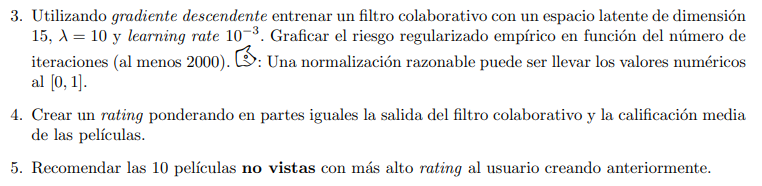

In [43]:
class Recomendador:
  def __init__(self, alpha, reg, n_it, nu, p, data):
    self.alpha = alpha
    self.reg = reg
    self.n_it = n_it

    self.nu = nu
    self.p = p

    self.titulos = np.array(data['title'].astype(str).to_list())


    self.Y = data.drop(columns=['title']).values #me quedo solo con los valores
    self.mascara = self.Y != -1

    min_val = np.min(self.Y[self.mascara])
    max_val = np.max(self.Y[self.mascara])
    self.Y = (self.Y - min_val) / (max_val - min_val)
    self.Y[~self.mascara] = -1.0


    suma_ratings_por_anime = np.sum(self.Y, axis = 1, where=self.mascara)
    conteo_ratings_por_anime = np.sum(self.mascara, axis = 1)

    self.promedio_animes = np.divide(suma_ratings_por_anime, conteo_ratings_por_anime, where = conteo_ratings_por_anime!=0)

    self.X = np.random.rand(self.Y.shape[0], self.nu) * 0.01
    self.Thita = np.random.rand(self.Y.shape[1], self.nu) * 0.01


    self.error = []
    self.ratings = None


  def fit(self):

    for i in range(self.n_it):
      E = (self.X @ self.Thita.T - self.Y) * self.mascara

      self.error.append(np.sum(E**2) + self.reg * (np.sum(self.X**2) + np.sum(self.Thita**2)))

      self.X = self.X - self.alpha * (E @ self.Thita + self.reg * self.X)

      self.Thita = self.Thita - self.alpha * (E.T @ self.X + self.reg * self.Thita)


    self.ratings = self.X @ self.Thita.T

    return self.ratings, self.error

  def rating(self, j): #da el rating para el j-ésimo usuario y para todos los animes

    return self.p * self.ratings[:, j] + (1 - self.p) * self.promedio_animes


  def recomendar(self, k, j): #k valores máximos del rating no valorados todavía por el usuario
    ratings = self.rating(j)

    #copio para no modificar el original
    ratings_copy = np.copy(ratings)

    #Lo pongo en -inf para que no lo seleccione el argsort
    ratings_copy[self.mascara[:, j]] = -np.inf

    indices = np.flip(np.argsort(ratings_copy))[0:k]

    return self.titulos[indices]

In [44]:
n_it = 2000
p = 0.5
recomendador = Recomendador(alpha = 1e-3, reg = 10, n_it = n_it, nu = 15, p = p, data = df)
ratings, error = recomendador.fit()

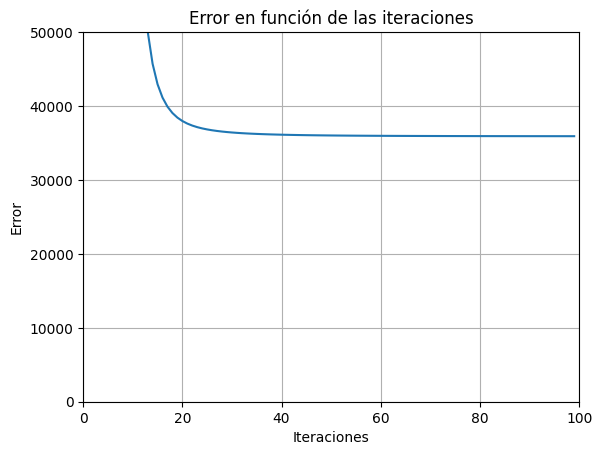

In [45]:
plt.plot(error)
plt.title('Error en función de las iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel('Error')
plt.xlim(0, n_it)
plt.ylim(0, 50000)
plt.grid(True)

In [46]:
recomendaciones = recomendador.recomendar(10, 1000)
print(recomendaciones)

['Steins;Gate' "Frieren: Beyond Journey's End" 'Hunter x Hunter'
 'Gintama Season 4' 'Monogatari Series: Second Season'
 'March Comes In Like a Lion 2nd Season' 'Mushi-shi: Next Passage Part 1'
 'The Apothecary Diaries' 'Mushi-shi: Next Passage Part 2'
 'Mob Psycho 100 II']


El algoritmo no recomienda nada de Pokémon ¿Por qué?
El algoritmo no se guía por tópicos o los nombres de las series. Solo ve qué usuarios valoraron de forma similar y recomienda en base a eso.